In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"../data/Amazon.csv")
print(df.head()) 
print(df.shape)
print(df.columns)
print(df.info()) 

                         Timestamp  age             Gender  \
0   2023/06/08 7:50:55 PM GMT+5:30   65  Prefer not to say   
1   2023/06/09 9:37:44 AM GMT+5:30   20               Male   
2  2023/06/11 11:26:54 PM GMT+5:30   42               Male   
3   2023/06/08 5:17:10 PM GMT+5:30   65             Others   
4  2023/06/11 10:59:30 PM GMT+5:30   45             Female   

       Purchase_Frequency                                Purchase_Categories  \
0  Less than once a month                               Clothing and Fashion   
1             Once a week  Groceries and Gourmet Food;Beauty and Personal...   
2             Once a week  Groceries and Gourmet Food;Beauty and Personal...   
3            Once a month  Beauty and Personal Care;Clothing and Fashion;...   
4             Once a week  Beauty and Personal Care;Clothing and Fashion;...   

  Personalized_Recommendation_Frequency    Browsing_Frequency  \
0                                   Yes  Multiple times a day   
1               

In [3]:
df.columns = df.columns.str.strip()

In [4]:
duplicate_columns = df.columns[df.columns.duplicated()].tolist()
duplicate_columns

['Personalized_Recommendation_Frequency']

In [5]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Timestamp
1 age
2 Gender
3 Purchase_Frequency
4 Purchase_Categories
5 Personalized_Recommendation_Frequency
6 Browsing_Frequency
7 Product_Search_Method
8 Search_Result_Exploration
9 Customer_Reviews_Importance
10 Add_to_Cart_Browsing
11 Cart_Completion_Frequency
12 Cart_Abandonment_Factors
13 Saveforlater_Frequency
14 Review_Left
15 Review_Reliability
16 Review_Helpfulness
17 Personalized_Recommendation_Frequency
18 Recommendation_Helpfulness
19 Rating_Accuracy
20 Shopping_Satisfaction
21 Service_Appreciation
22 Improvement_Areas
23 transaction


In [6]:
cols = list(df.columns)

cols[5] = "Recommendation_Response"
cols[17] = "Recommendation_Score"

df.columns = cols

In [7]:
columns = [
    "Gender",
    "Purchase_Frequency",
    "Recommendation_Helpfulness",
    "Review_Reliability",
    "Product_Search_Method"
]

for col in columns:
    print("=" * 50)
    print(f"Column: {col}")
    print("=" * 50)
    
    print(f"Unique Values ({df[col].nunique()}):")
    print(df[col].unique())
    
    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))
    
    print("\n")

Column: Gender
Unique Values (4):
<StringArray>
['Prefer not to say', 'Male', 'Others', 'Female']
Length: 4, dtype: str

Value Counts:
Gender
Male                 209
Others               202
Female               197
Prefer not to say    192
Name: count, dtype: int64


Column: Purchase_Frequency
Unique Values (5):
<StringArray>
['Less than once a month',            'Once a week',           'Once a month',
      'Few times a month',  'Multiple times a week']
Length: 5, dtype: str

Value Counts:
Purchase_Frequency
Once a month              168
Once a week               159
Multiple times a week     159
Few times a month         158
Less than once a month    156
Name: count, dtype: int64


Column: Recommendation_Helpfulness
Unique Values (3):
<StringArray>
['Sometimes', 'No', 'Yes']
Length: 3, dtype: str

Value Counts:
Recommendation_Helpfulness
Yes          270
Sometimes    268
No           262
Name: count, dtype: int64


Column: Review_Reliability
Unique Values (5):
<StringArray>
['Mode

In [8]:
# Replacing null value with Unknown in Product_Search_Method
df["Product_Search_Method"] = df["Product_Search_Method"].fillna("Unknown")
df["Product_Search_Method"] = df["Product_Search_Method"].str.strip().str.title()

In [9]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Recommendation_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,No,Sometimes,Found a better price elsewhere,Sometimes,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,No,Never,High shipping costs,Always,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,No,Rarely,Found a better price elsewhere,Often,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,Yes,Sometimes,others,Often,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Unknown,First page,5,Maybe,Rarely,Changed my mind or no longer need the item,Never,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


# Task 2

In [10]:
print(df["age"].describe())

count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64


In [11]:
bins = [0, 12, 19, 35, 50, np.inf]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["Age_Group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [12]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Recommendation_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Age_Group
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,No,Sometimes,Found a better price elsewhere,Sometimes,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242,Senior
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,No,Never,High shipping costs,Always,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,Young Adult
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,No,Rarely,Found a better price elsewhere,Often,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975,Adult
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,Yes,Sometimes,others,Often,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872,Senior
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Unknown,First page,5,Maybe,Rarely,Changed my mind or no longer need the item,Never,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642,Adult


In [13]:
df[["age", "Age_Group"]].head()

,age,Age_Group
0,65,Senior
1,20,Young Adult
2,42,Adult
3,65,Senior
4,45,Adult


In [14]:
df["Age_Group"].value_counts()

Age_Group
Senior         215
Young Adult    195
Adult          185
Child          123
Teen            82
Name: count, dtype: int64

In [15]:
df["Gender"].value_counts()

Gender
Male                 209
Others               202
Female               197
Prefer not to say    192
Name: count, dtype: int64

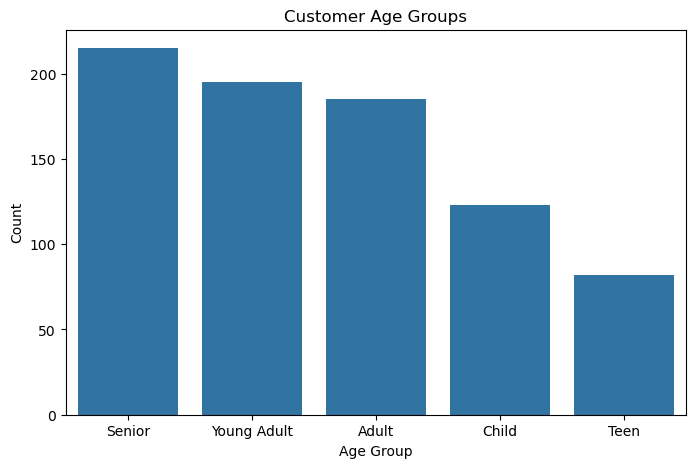

In [16]:


plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Age_Group"],
    order=df["Age_Group"].value_counts().index
)

plt.title("Customer Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

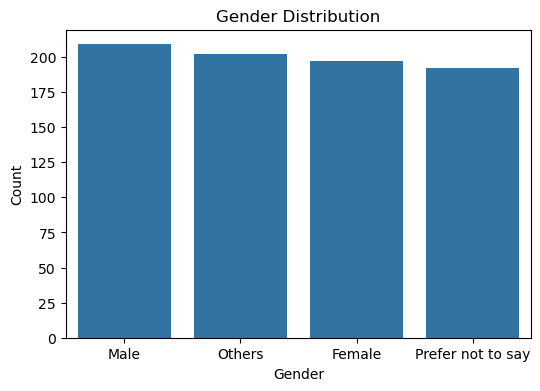

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Gender"], order=df["Gender"].value_counts().index)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [18]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Recommendation_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Age_Group
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,No,Sometimes,Found a better price elsewhere,Sometimes,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242,Senior
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,No,Never,High shipping costs,Always,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,Young Adult
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,No,Rarely,Found a better price elsewhere,Often,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975,Adult
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,Yes,Sometimes,others,Often,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872,Senior
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Unknown,First page,5,Maybe,Rarely,Changed my mind or no longer need the item,Never,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642,Adult


In [19]:
df["Purchase_Frequency"].value_counts()

Purchase_Frequency
Once a month              168
Once a week               159
Multiple times a week     159
Few times a month         158
Less than once a month    156
Name: count, dtype: int64

In [20]:
df["Purchase_Categories"] = df["Purchase_Categories"].str.split(';')

In [21]:
category_df = df.explode("Purchase_Categories")

In [22]:
category_df["Purchase_Categories"].value_counts()

Purchase_Categories
Clothing and Fashion          450
others                        412
Home and Kitchen              391
Beauty and Personal Care      383
Groceries and Gourmet Food    369
Name: count, dtype: int64

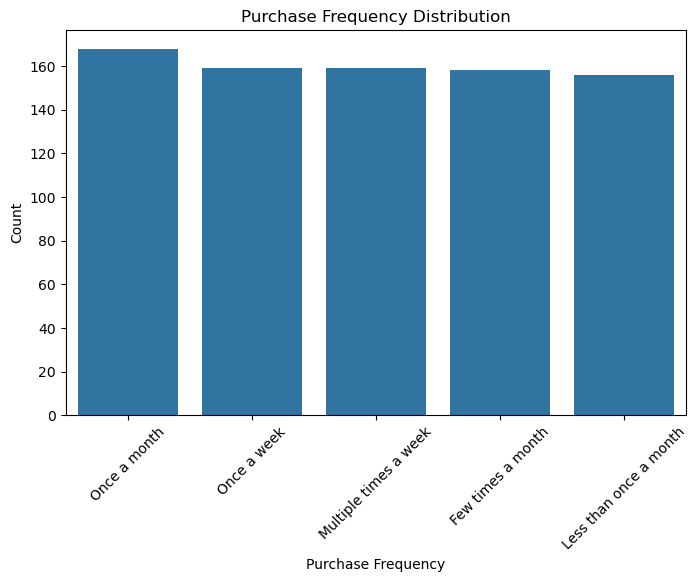

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Purchase_Frequency"],
    order=df["Purchase_Frequency"].value_counts().index
) 

plt.title("Purchase Frequency Distribution")
plt.xlabel("Purchase Frequency") 
plt.ylabel("Count")

plt.xticks(rotation= 45) 
plt.show()

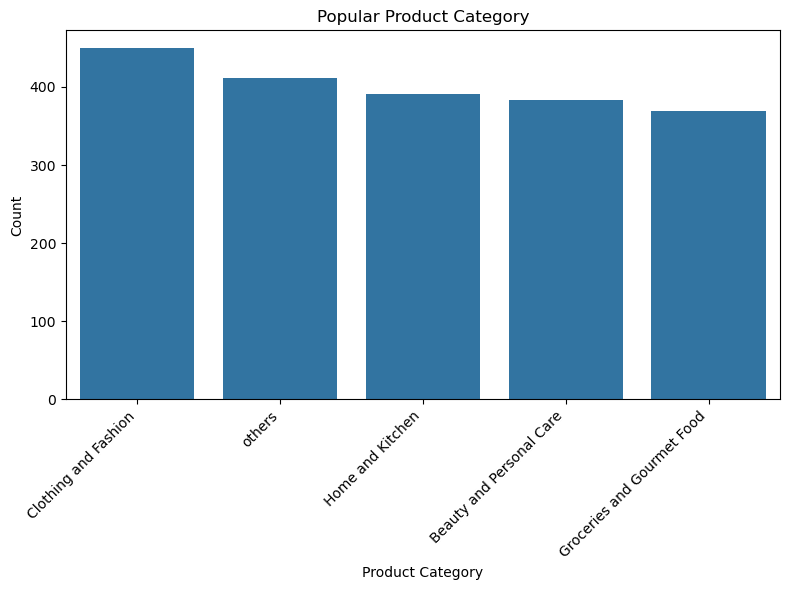

In [24]:
plt.figure(figsize=(8,6))

sns.countplot(
    x=category_df["Purchase_Categories"],
    order=category_df["Purchase_Categories"].value_counts().index 
) 
plt.title("Popular Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count") 
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()

In [25]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Recommendation_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Age_Group
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,[Clothing and Fashion],Yes,Multiple times a day,Keyword,Multiple pages,2,No,Sometimes,Found a better price elsewhere,Sometimes,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242,Senior
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,"[Groceries and Gourmet Food, Beauty and Person...",No,Rarely,Filter,First page,3,No,Never,High shipping costs,Always,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,Young Adult
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,"[Groceries and Gourmet Food, Beauty and Person...",Sometimes,Few times a week,Keyword,Multiple pages,2,No,Rarely,Found a better price elsewhere,Often,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975,Adult
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,"[Beauty and Personal Care, Clothing and Fashio...",No,Few times a month,Filter,Multiple pages,2,Yes,Sometimes,others,Often,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872,Senior
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,"[Beauty and Personal Care, Clothing and Fashio...",Sometimes,Few times a month,Unknown,First page,5,Maybe,Rarely,Changed my mind or no longer need the item,Never,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642,Adult


In [26]:
df["Browsing_Frequency"].value_counts()

Browsing_Frequency
Rarely                  231
Few times a month       200
Few times a week        186
Multiple times a day    183
Name: count, dtype: int64

In [27]:
df["Product_Search_Method"].value_counts()

Product_Search_Method
Keyword       170
Categories    163
Filter        161
Unknown       157
Others        149
Name: count, dtype: int64

In [28]:
df["Cart_Abandonment_Factors"].value_counts()

Cart_Abandonment_Factors
High shipping costs                           224
Found a better price elsewhere                206
Changed my mind or no longer need the item    194
others                                        176
Name: count, dtype: int64

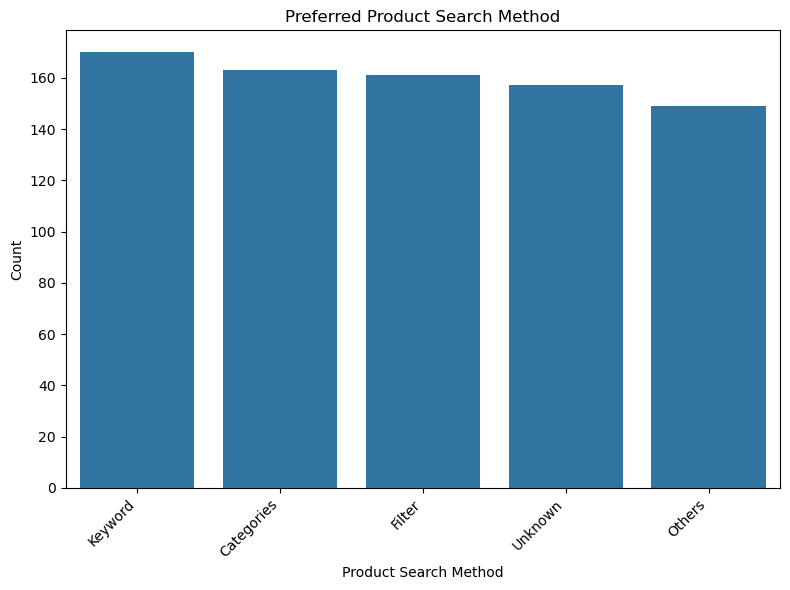

In [29]:
plt.figure(figsize=(8,6))

sns.countplot(
    x=df["Product_Search_Method"],
    order=df["Product_Search_Method"].value_counts().index 
) 
plt.title("Preferred Product Search Method")
plt.xlabel("Product Search Method")
plt.ylabel("Count") 
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()

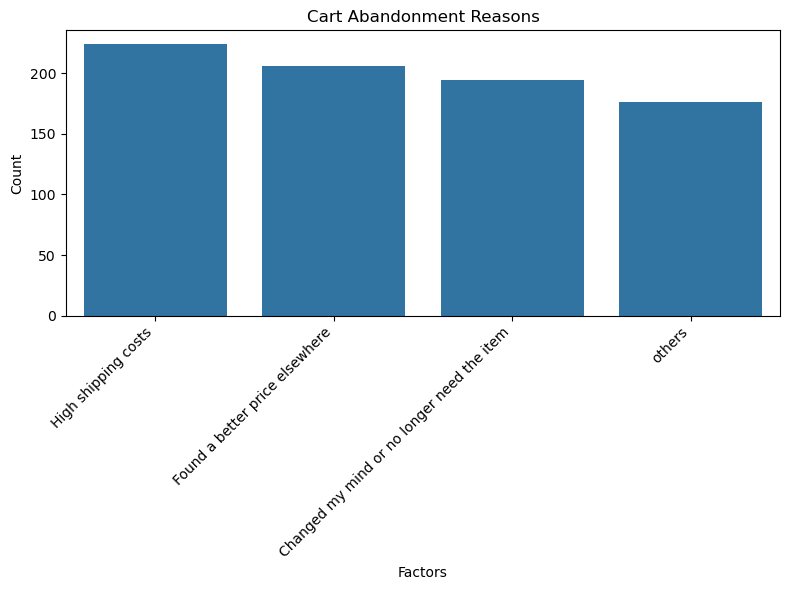

In [30]:
plt.figure(figsize=(8,6))

sns.countplot(
    x=df["Cart_Abandonment_Factors"],
    order=df["Cart_Abandonment_Factors"].value_counts().index 
) 
plt.title("Cart Abandonment Reasons")
plt.xlabel("Factors")
plt.ylabel("Count") 
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()

In [31]:
#Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy
print("Mean Satisfaction:", df["Shopping_Satisfaction"].mean())
print("Median Satisfaction:", df["Shopping_Satisfaction"].median())

print("\nMean Recommendation Score:", df["Recommendation_Score"].mean())
print("Median Recommendation Score:", df["Recommendation_Score"].median()) 

print("\nMean Rating Accuracy:", df["Rating_Accuracy"].mean())
print("Median Rating Accuracy:", df["Rating_Accuracy"].median())

print("\n", df["Recommendation_Helpfulness"].value_counts())

Mean Satisfaction: 3.0125
Median Satisfaction: 3.0

Mean Recommendation Score: 2.9525
Median Recommendation Score: 3.0

Mean Rating Accuracy: 2.96875
Median Rating Accuracy: 3.0

 Recommendation_Helpfulness
Yes          270
Sometimes    268
No           262
Name: count, dtype: int64


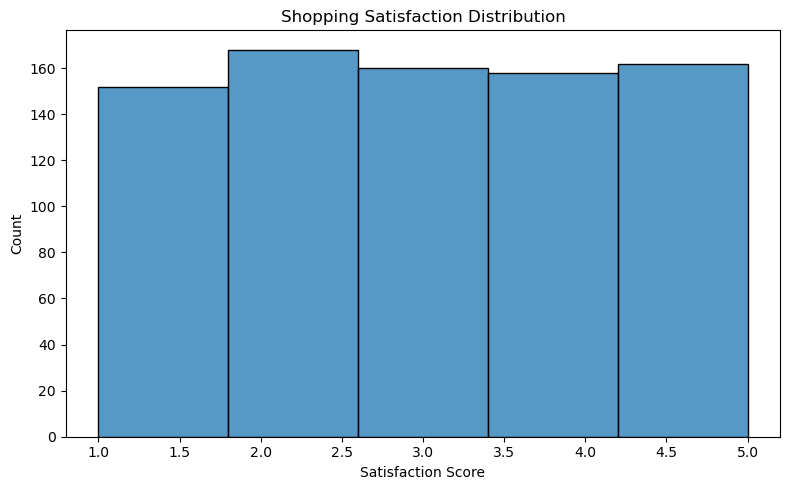

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["Shopping_Satisfaction"], bins= 5) 
plt.title("Shopping Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

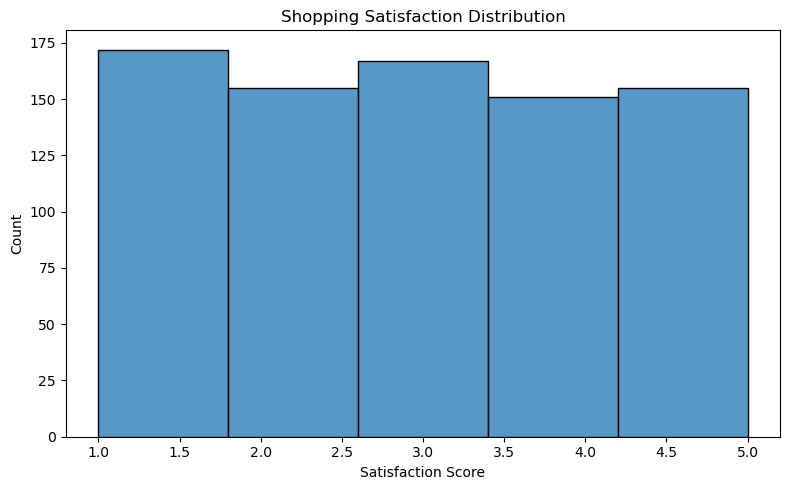

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["Recommendation_Score"], bins= 5) 
plt.title("Shopping Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

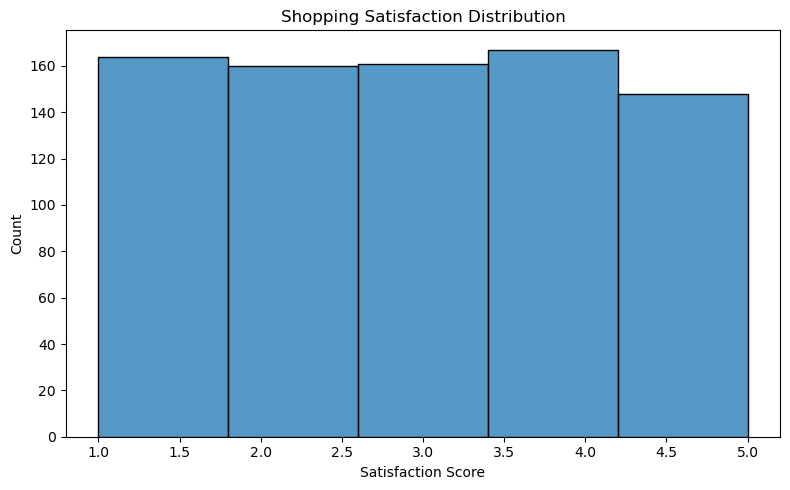

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating_Accuracy"], bins= 5) 
plt.title("Shopping Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [35]:
num_cols = [
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy"
]

corr = df[num_cols].corr()

corr

,Shopping_Satisfaction,Customer_Reviews_Importance,Rating_Accuracy
Shopping_Satisfaction,1.000000,-0.037009,-0.015644
Customer_Reviews_Importance,-0.037009,1.000000,0.036391
Rating_Accuracy,-0.015644,0.036391,1.000000


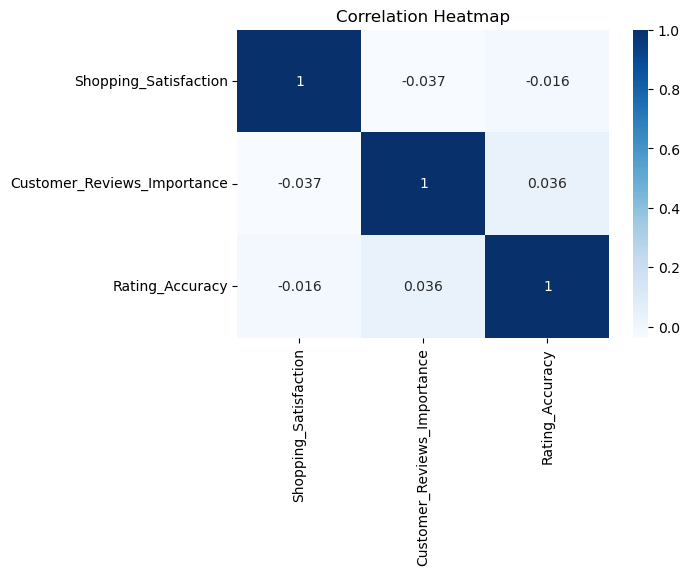

In [36]:
plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

### Insight
- Most customers shop monthly.
- Electronics is the dominant category.
- Customers highly value reliable reviews.

# Customer Profiling and Insights

In [37]:
#Segment customers based on purchase frequency and shopping satisfaction levels.
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Recommendation_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Age_Group
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,[Clothing and Fashion],Yes,Multiple times a day,Keyword,Multiple pages,2,No,Sometimes,Found a better price elsewhere,Sometimes,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242,Senior
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,"[Groceries and Gourmet Food, Beauty and Person...",No,Rarely,Filter,First page,3,No,Never,High shipping costs,Always,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,Young Adult
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,"[Groceries and Gourmet Food, Beauty and Person...",Sometimes,Few times a week,Keyword,Multiple pages,2,No,Rarely,Found a better price elsewhere,Often,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975,Adult
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,"[Beauty and Personal Care, Clothing and Fashio...",No,Few times a month,Filter,Multiple pages,2,Yes,Sometimes,others,Often,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872,Senior
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,"[Beauty and Personal Care, Clothing and Fashio...",Sometimes,Few times a month,Unknown,First page,5,Maybe,Rarely,Changed my mind or no longer need the item,Never,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642,Adult


In [38]:
print(df["Purchase_Frequency"].value_counts())
print()
print(df["Shopping_Satisfaction"].value_counts())

Purchase_Frequency
Once a month              168
Once a week               159
Multiple times a week     159
Few times a month         158
Less than once a month    156
Name: count, dtype: int64

Shopping_Satisfaction
2    168
5    162
3    160
4    158
1    152
Name: count, dtype: int64


In [39]:
# Customer Segmentation 
## Frequent Buyers: High purchase frequency, high satisfaction. 
## Occasional Shoppers: Medium frequency, moderate satisfaction. 
## At-Risk Customers: Low satisfaction or frequent cart abandonment. 
purchase_rank = { "Multiple times a week": 5, "Once a week":4 , "Few times a month":3, "Once a month":2, "Less than once a month":1} 
df["Purchase_Frequency_Rank"]= df["Purchase_Frequency"].map(purchase_rank)

In [40]:
df[["Purchase_Frequency", "Purchase_Frequency_Rank"]].head()

,Purchase_Frequency,Purchase_Frequency_Rank
0,Less than once a month,1
1,Once a week,4
2,Once a week,4
3,Once a month,2
4,Once a week,4


In [41]:
def customer_segementation(df):
    if df["Shopping_Satisfaction"] >=4 and df["Purchase_Frequency_Rank"] >= 4:
        return "Frequent Buyer" 
    elif df["Shopping_Satisfaction"] <=2 and df["Purchase_Frequency_Rank"] <= 2:
        return "At-Risk Customer"
    else:
        return "Occasional Buyer" 

df["Customer_Segment"] = df.apply(customer_segementation, axis=1)
print("Customer Segmentation Count")
print(df["Customer_Segment"].value_counts())

Customer Segmentation Count
Customer_Segment
Occasional Buyer    530
Frequent Buyer      135
At-Risk Customer    135
Name: count, dtype: int64


In [42]:
pd.crosstab(
    df["Customer_Segment"],
    df["Gender"]
) 

Gender,Female,Male,Others,Prefer not to say
Customer_Segment,,,,
At-Risk Customer,34,42,29,30
Frequent Buyer,30,35,31,39
Occasional Buyer,133,132,142,123


In [43]:
pd.crosstab(
    df["Customer_Segment"],
    df["Age_Group"]
)

Age_Group,Child,Teen,Young Adult,Adult,Senior
Customer_Segment,,,,,
At-Risk Customer,20,18,30,35,32
Frequent Buyer,19,15,34,33,34
Occasional Buyer,84,49,131,117,149


In [44]:
pd.crosstab(
    df["Customer_Segment"],
    df["Purchase_Frequency"]
)

Purchase_Frequency,Few times a month,Less than once a month,Multiple times a week,Once a month,Once a week
Customer_Segment,,,,,
At-Risk Customer,0,64,0,71,0
Frequent Buyer,0,0,75,0,60
Occasional Buyer,158,92,84,97,99


In [45]:
pd.crosstab(
    df["Customer_Segment"],
    df["Shopping_Satisfaction"]
)

Shopping_Satisfaction,1,2,3,4,5
Customer_Segment,,,,,
At-Risk Customer,60,75,0,0,0
Frequent Buyer,0,0,0,66,69
Occasional Buyer,92,93,160,92,93


In [46]:
# Kmeans Clustering
features = ["Purchase_Frequency_Rank", "Shopping_Satisfaction" ]

from sklearn.cluster import KMeans

x = df[features] 
kmeans = KMeans(n_clusters=3, random_state=42) 
df["Cluster"] = kmeans.fit_predict(x)

C:\Users\Himanshu\anaconda3\envs\marketBasketAnalysisAmazon\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [47]:
df.head() 

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Recommendation_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Age_Group,Purchase_Frequency_Rank,Customer_Segment,Cluster
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,[Clothing and Fashion],Yes,Multiple times a day,Keyword,Multiple pages,2,No,Sometimes,Found a better price elsewhere,Sometimes,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242,Senior,1,Occasional Buyer,2
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,"[Groceries and Gourmet Food, Beauty and Person...",No,Rarely,Filter,First page,3,No,Never,High shipping costs,Always,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,Young Adult,4,Frequent Buyer,0
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,"[Groceries and Gourmet Food, Beauty and Person...",Sometimes,Few times a week,Keyword,Multiple pages,2,No,Rarely,Found a better price elsewhere,Often,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975,Adult,4,Occasional Buyer,0
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,"[Beauty and Personal Care, Clothing and Fashio...",No,Few times a month,Filter,Multiple pages,2,Yes,Sometimes,others,Often,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872,Senior,2,At-Risk Customer,1
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,"[Beauty and Personal Care, Clothing and Fashio...",Sometimes,Few times a month,Unknown,First page,5,Maybe,Rarely,Changed my mind or no longer need the item,Never,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642,Adult,4,Occasional Buyer,1


In [48]:
df["Cluster"].value_counts() 

Cluster
0    319
1    254
2    227
Name: count, dtype: int64

- Cluster 0 → Loyal Customers
- Cluster 1 → Value Seekers
- Cluster 2 → Low Engagement Customers

# Task 4
- Examine the relationship between recommendation helpfulness and shopping satisfaction. 
- Evaluate how review reliability and helpfulness impact overall ratings. 
- Identify trends in how often customers engage with or trust personalized recommendations. 
- Suggest actionable insights for improving Amazon’s recommendation system.

In [49]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Recommendation_Response', 'Browsing_Frequency',
       'Product_Search_Method', 'Search_Result_Exploration',
       'Customer_Reviews_Importance', 'Add_to_Cart_Browsing',
       'Cart_Completion_Frequency', 'Cart_Abandonment_Factors',
       'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability',
       'Review_Helpfulness', 'Recommendation_Score',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas',
       'transaction', 'Age_Group', 'Purchase_Frequency_Rank',
       'Customer_Segment', 'Cluster'],
      dtype='str')

In [51]:
# Recommendation_Helpfulness
# Shopping_Satisfaction 

# Review_Helpfulness
# Review_Reliability
# Rating_Accuracy

# Recommendation_Score
# Recommendation_Response

In [64]:
cols = ["Recommendation_Helpfulness","Shopping_Satisfaction","Review_Helpfulness","Review_Reliability",
        "Rating_Accuracy","Recommendation_Score","Recommendation_Response"]
for col in cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Recommendation_Helpfulness
Recommendation_Helpfulness
Yes          270
Sometimes    268
No           262
Name: count, dtype: int64

Shopping_Satisfaction
Shopping_Satisfaction
2    168
5    162
3    160
4    158
1    152
Name: count, dtype: int64

Review_Helpfulness
Review_Helpfulness
No           289
Yes          257
Sometimes    254
Name: count, dtype: int64

Review_Reliability
Review_Reliability
Heavily         167
Never           166
Occasionally    161
Moderately      156
Rarely          150
Name: count, dtype: int64

Rating_Accuracy
Rating_Accuracy
4    167
1    164
3    161
2    160
5    148
Name: count, dtype: int64

Recommendation_Score
Recommendation_Score
1    172
3    167
2    155
5    155
4    151
Name: count, dtype: int64

Recommendation_Response
Recommendation_Response
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64


In [67]:
df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"].agg(['mean','count'])

,mean,count
Recommendation_Helpfulness,,
No,3.041985,262
Sometimes,2.955224,268
Yes,3.040741,270


In [68]:
pd.crosstab(
    df["Recommendation_Helpfulness"],
    df["Shopping_Satisfaction"])

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
No,49,52,52,57,52
Sometimes,57,55,52,51,53
Yes,46,61,56,50,57


In [71]:
from scipy.stats import f_oneway

no = df.loc[
    df["Recommendation_Helpfulness"]=="No",
    "Shopping_Satisfaction"
]

sometimes = df.loc[
    df["Recommendation_Helpfulness"]=="Sometimes",
    "Shopping_Satisfaction"
]

yes = df.loc[
    df["Recommendation_Helpfulness"]=="Yes",
    "Shopping_Satisfaction"
]

f_stat, p_value = f_oneway(no, sometimes, yes)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.3333859188866901
P-value: 0.7165935027365737


Shopping_Satisfaction,1,2,3,4,5
Recommendation_Helpfulness,,,,,
No,18.702290,19.847328,19.847328,21.755725,19.847328
Sometimes,21.268657,20.522388,19.402985,19.029851,19.776119
Yes,17.037037,22.592593,20.740741,18.518519,21.111111


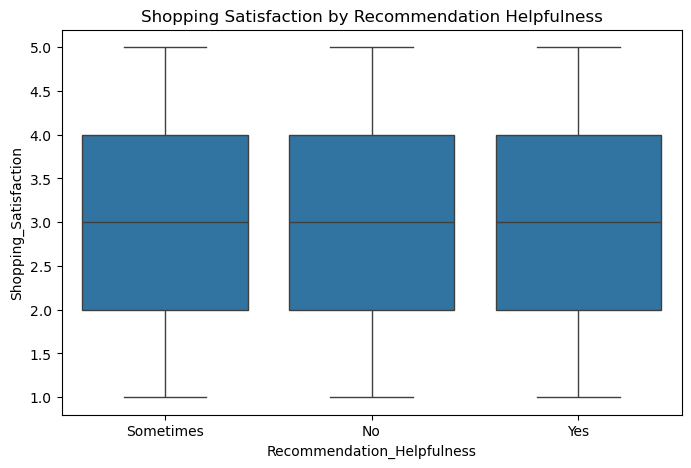

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Recommendation_Helpfulness",
    y="Shopping_Satisfaction",
    data=df
)

plt.title(
    "Shopping Satisfaction by Recommendation Helpfulness"
)

plt.show()

In [74]:
pd.crosstab(
    df["Review_Reliability"],
    df["Rating_Accuracy"]
)

Rating_Accuracy,1,2,3,4,5
Review_Reliability,,,,,
Heavily,30,28,42,42,25
Moderately,25,34,19,40,38
Never,41,35,30,29,31
Occasionally,37,31,36,32,25
Rarely,31,32,34,24,29


In [75]:
df.groupby(
    "Review_Reliability"
)["Rating_Accuracy"].mean()

Review_Reliability
Heavily         3.023952
Moderately      3.205128
Never           2.843373
Occasionally    2.857143
Rarely          2.920000
Name: Rating_Accuracy, dtype: float64

<Axes: xlabel='Review_Reliability', ylabel='Rating_Accuracy'>

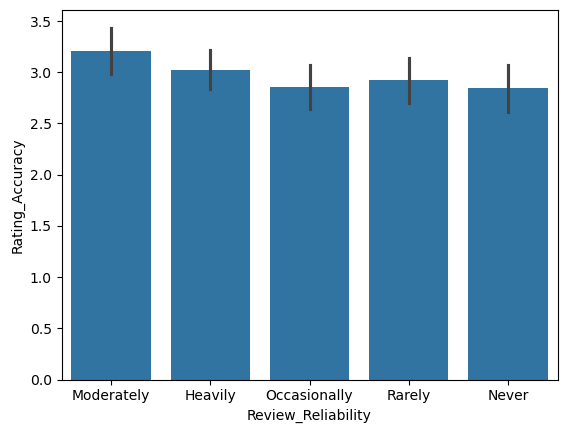

In [76]:
sns.barplot(
    x="Review_Reliability",
    y="Rating_Accuracy",
    data=df
)

In [77]:
pd.crosstab(
    df["Review_Helpfulness"],
    df["Shopping_Satisfaction"]
)

Shopping_Satisfaction,1,2,3,4,5
Review_Helpfulness,,,,,
No,60,65,56,59,49
Sometimes,46,47,58,48,55
Yes,46,56,46,51,58


In [78]:
df.groupby(
    "Review_Helpfulness"
)["Shopping_Satisfaction"].mean()

Review_Helpfulness
No           2.903114
Sometimes    3.074803
Yes          3.073930
Name: Shopping_Satisfaction, dtype: float64

<Axes: xlabel='Review_Helpfulness', ylabel='Shopping_Satisfaction'>

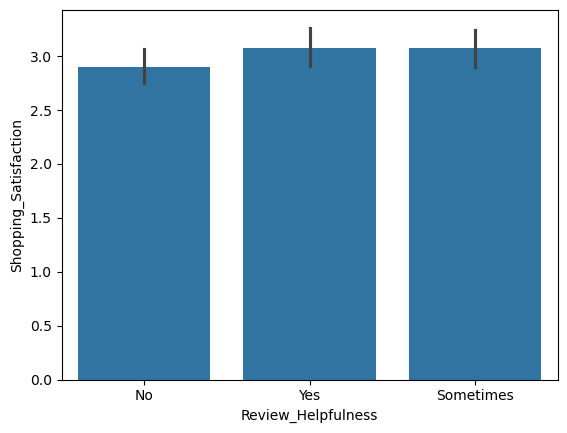

In [79]:
sns.barplot(
    x="Review_Helpfulness",
    y="Shopping_Satisfaction",
    data=df
)

In [80]:
df["Recommendation_Response"].value_counts()

Recommendation_Response
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64

In [81]:
df["Recommendation_Score"].value_counts()

Recommendation_Score
1    172
3    167
2    155
5    155
4    151
Name: count, dtype: int64

In [82]:
pd.crosstab(
    df["Recommendation_Response"],
    df["Shopping_Satisfaction"]
)

Shopping_Satisfaction,1,2,3,4,5
Recommendation_Response,,,,,
No,51,59,49,60,53
Sometimes,53,48,59,40,50
Yes,48,61,52,58,59


In [85]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Recommendation_Response', 'Browsing_Frequency',
       'Product_Search_Method', 'Search_Result_Exploration',
       'Customer_Reviews_Importance', 'Add_to_Cart_Browsing',
       'Cart_Completion_Frequency', 'Cart_Abandonment_Factors',
       'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability',
       'Review_Helpfulness', 'Recommendation_Score',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas',
       'transaction', 'Age_Group', 'Purchase_Frequency_Rank',
       'Customer_Segment', 'Cluster'],
      dtype='str')

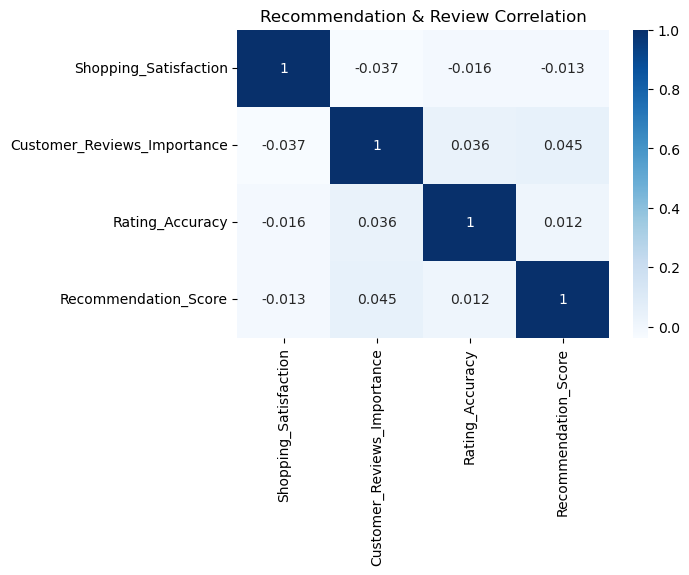

In [86]:
cols = [
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy",
    "Recommendation_Score"
]
corr = df[cols].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Recommendation & Review Correlation")

plt.show()

In [87]:
for col in [
    "Recommendation_Helpfulness",
    "Review_Reliability",
    "Review_Helpfulness",
    "Recommendation_Response"
]:
    print("\n", col)
    print(df[col].value_counts())


 Recommendation_Helpfulness
Recommendation_Helpfulness
Yes          270
Sometimes    268
No           262
Name: count, dtype: int64

 Review_Reliability
Review_Reliability
Heavily         167
Never           166
Occasionally    161
Moderately      156
Rarely          150
Name: count, dtype: int64

 Review_Helpfulness
Review_Helpfulness
No           289
Yes          257
Sometimes    254
Name: count, dtype: int64

 Recommendation_Response
Recommendation_Response
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64
